In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

In [11]:
# --- 1. Parameters ---
mPsi = 1000.0  # Heavy Vector-Like Quark Mass (GeV)
mT = 0.0       # Top Mass (Approximation)
pi = np.pi

# --- 2. Kinematic Functions ---
def get_kinematics(s_val, m):
    """
    Calculates L(s) and Delta(s).
    Using complex types to handle regimes below and above threshold.
    """
    # Force complex arithmetic by adding 0j
    s = s_val.astype(complex)
    
    # Delta = Sqrt[s * (s - 4m^2)]
    delta = np.sqrt(s * (s - 4 * m**2))
    
    # L = Log[(2m^2 - s + delta) / (2m^2)]
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    
    return L, delta

def get_prefactor(s):
    # Global Scale: -1 / (32 * pi^4 * s^2)
    return -1.0 / (32.0 * pi**4 * s**2)

# --- 3. Coefficient Groups ---
def calculate_coefficients(s_vals):
    L, delta = get_kinematics(s_vals, mPsi)
    scale = get_prefactor(s_vals)
    
    # Group 1: Gamma Term (Dimensionless)
    # Structure: s * ((m^2 + M^2)*L^2 + L*Delta + 3s)
    coeff_gamma = scale * s_vals * ((mPsi**2 + mT**2) * L**2 + L * delta + 3 * s_vals)
    
    # Group 2: Sandwich Term (Dimension -1)
    # Structure: -1 * (s*(L^2 + 4) + 2*L*Delta)
    # Scaled by mPsi to make it dimensionless for plotting
    coeff_sandwich = (scale * -1 * (s_vals * (L**2 + 4) + 2 * L * delta)) * mPsi
    
    # Group 3: Diagonal Vector Term (Dimension -1)
    # Structure: 2 * (L*Delta + 2s)
    # Scaled by mPsi
    coeff_vec_diag = (scale * 2 * (L * delta + 2 * s_vals)) * mPsi
    
    # Group 4: Mixed Vector Term (Dimension -1)
    # Structure: -2 * (m^2*L^2 + 2*L*Delta + 5s)
    # Scaled by mPsi
    coeff_vec_mix = (scale * -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s_vals)) * mPsi
    
    return coeff_gamma, coeff_sandwich, coeff_vec_diag, coeff_vec_mix

In [12]:
# Define energy range (Sqrt[s])
# Start from 173 GeV (Top mass) up to 5000 GeV (5 TeV)
energy_range = np.linspace(173, 5000, 1000) 
s_values = energy_range**2

# Calculate all coefficients
c_gamma, c_sand, c_v_diag, c_v_mix = calculate_coefficients(s_values)

# Threshold for plotting vertical lines
threshold = 2 * mPsi

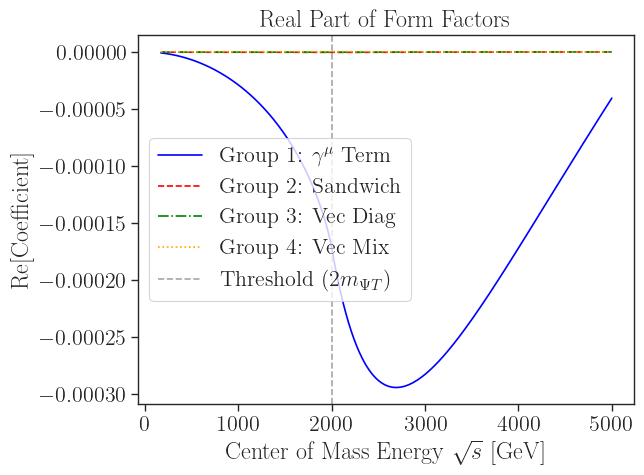

In [13]:
fig, ax = plt.subplots()

ax.plot(energy_range, np.real(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.real(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.real(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.real(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Real Part of Form Factors")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Re[Coefficient]")
ax.legend()

plt.show()

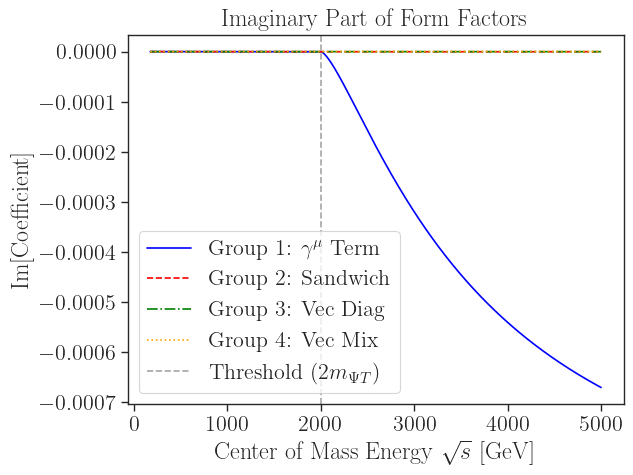

In [14]:
fig, ax = plt.subplots()

ax.plot(energy_range, np.imag(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.imag(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.imag(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.imag(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Imaginary Part of Form Factors")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Im[Coefficient]")
ax.legend()

plt.show()

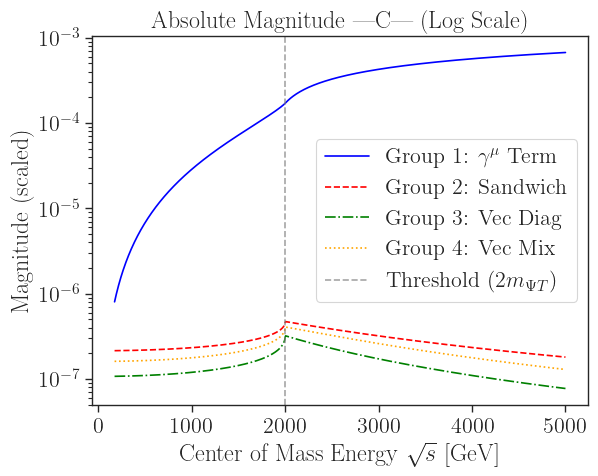

In [15]:
fig, ax = plt.subplots()

# Use absolute value
ax.plot(energy_range, np.abs(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.abs(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.abs(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.abs(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Log scale for Y axis
ax.set_yscale('log')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Absolute Magnitude |C| (Log Scale)")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Magnitude (scaled)")
ax.legend()

plt.show()

In [16]:
print("--- ANALYSIS OF THE FORM FACTOR BEHAVIOR ---")

# Check values exactly at threshold (approximate index)
idx_thresh = np.abs(energy_range - threshold).argmin()

print(f"1. Threshold Location: {threshold} GeV")
print(f"   At this energy, the loop particles (mass {mPsi} GeV) can be produced on-shell.")
print("-" * 40)
print("2. Cusp Behavior (Real Part):")
print("   You should observe a sharp 'kink' or peak in the Real Part plot at 2000 GeV.")
print(f"   Re[Gamma] at threshold: {np.real(c_gamma[idx_thresh]):.4e}")
print("-" * 40)
print("3. Imaginary Part Onset:")
print("   Below 2000 GeV, the Imaginary part should be exactly zero.")
print(f"   Im[Gamma] at 1000 GeV: {np.imag(c_gamma[np.abs(energy_range - 1000).argmin()]):.4e}")
print(f"   Im[Gamma] at 3000 GeV: {np.imag(c_gamma[np.abs(energy_range - 3000).argmin()]):.4e}")
print("-" * 40)
print("4. Dominance:")
print("   In the Log plot, the Blue curve (Gamma term) is dominant.")
print("   The vector terms (scaled by mass) are of comparable order but distinct shapes.")

--- ANALYSIS OF THE FORM FACTOR BEHAVIOR ---
1. Threshold Location: 2000.0 GeV
   At this energy, the loop particles (mass 1000.0 GeV) can be produced on-shell.
----------------------------------------
2. Cusp Behavior (Real Part):
   You should observe a sharp 'kink' or peak in the Real Part plot at 2000 GeV.
   Re[Gamma] at threshold: -1.7061e-04
----------------------------------------
3. Imaginary Part Onset:
   Below 2000 GeV, the Imaginary part should be exactly zero.
   Im[Gamma] at 1000 GeV: 1.8709e-20
   Im[Gamma] at 3000 GeV: -3.2000e-04
----------------------------------------
4. Dominance:
   In the Log plot, the Blue curve (Gamma term) is dominant.
   The vector terms (scaled by mass) are of comparable order but distinct shapes.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

# --- 2. PARAMETERS ---
mPsi = 1000.0  # Mass (GeV)
mT = 0.0       # Top Mass approx
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_prefactor(s):
    return -1.0 / (32.0 * pi**4 * s**2)

# --- 4. CALCULATE DATA ---
# Energy range: Top Mass to 5 TeV
energy_range = np.linspace(173, 10000, 10000)
s_values = energy_range**2

# --- NEW: Define Normalized X-Axis ---
# We normalize sqrt(s) by the mass mPsi
x_norm = energy_range / mPsi  
# The threshold is now simply at 2.0 (since 2*mPsi / mPsi = 2)
threshold_norm = 2.0

L, delta = get_kinematics(s_values, mPsi)
scale = get_prefactor(s_values)

# Coefficients
c_gamma = scale * s_values * ((mPsi**2 + mT**2) * L**2 + L * delta + 3 * s_values)
c_sand = (scale * -1 * (s_values * (L**2 + 4) + 2 * L * delta)) * mPsi
c_v_diag = (scale * 2 * (L * delta + 2 * s_values)) * mPsi
c_v_mix = (scale * -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s_values)) * mPsi

# --- 5. PLOTTING ---
fig, ax = plt.subplots()

groups = [
fig_config = {'figsize': (18, 12), 'layout': 'constrained'}
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 2

mPsi = 1500.0
mT_approx = 0.0
pi = np.pi

def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_basis_coefficients(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    scale = 1.0 / (32.0 * pi**4 * s**2)
    
    raw_B1 = (mPsi**2 + mT**2) * L**2 + L * delta + 3 * s
    raw_B2 = -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s)
    raw_B3 = -(2 * L * delta + s * (L**2 + 4))
    raw_B4 = 2 * (L * delta + 2 * s)
    raw_B5 = 2 * (L * delta + 2 * s)

    c1 = scale * raw_B1
    c2 = scale * raw_B2
    c3 = scale * raw_B3
    c4 = scale * raw_B4
    c5 = scale * raw_B5
    
    return c1, c2, c3, c4, c5

def get_article_coefficients(s, mPsi):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    scalar_part = (1.0 / (32.0 * pi**4 * s**2)) * (mPsi**2 * L**2 + L * delta + 3 * s)
    
    c1_art = -scalar_part
    c2_art = 2.0 * scalar_part
    
    return c1_art, c2_art

x_axis = np.linspace(0.5, 8.0, 1000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

c1, c2, c3, c4, c5 = get_basis_coefficients(s_values, mPsi, mT_approx)
c1_art, c2_art = get_article_coefficients(s_values, mPsi)

fig, ax = plt.subplots(**fig_config)

m_scale = mPsi

lines_to_plot = [
    (c1_art, 'black', r'Ref $C_1$ (Article)', 1.5),
    (c2_art * m_scale, 'gray', r'Ref $C_2$ (Article)', 1.5),
    (c1, 'blue', r'Grp 1 ($F_1$)', 0),
    (c2 * m_scale, 'red', r'Grp 2 (Mixed)', 0),
    (c3 * m_scale, 'green', r'Grp 3 (Sand 2$\to$1)', 0),
    (c4 * m_scale, 'orange', r'Grp 4 (Sand 1$\to$2)', 0),
    (c5 * m_scale, 'purple', r'Grp 5 (Diag)', 0)
]

for data, col, lbl, w_off in lines_to_plot:
    base_lw = 2 + w_off
    ax.plot(x_axis, np.real(data), color=col, linestyle='-', linewidth=base_lw, label=f'{lbl} Re')
    ax.plot(x_axis, np.imag(data), color=col, linestyle='--', linewidth=base_lw, label=f'{lbl} Im')
    ax.plot(x_axis, np.abs(data), color=col, linestyle=':', linewidth=base_lw+1, label=f'{lbl} Abs')

ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Coefficient Value (SymLog Scale)")
ax.set_yscale('symlog', linthresh=1e-10)

ax.axvline(2.0, color='gray', linestyle='-', alpha=0.5)
ax.text(0.41, 0.95, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, ncol=1)

plt.show()
    (c_gamma, 'blue', r'Group 1 ($\gamma^\mu$)'),
    (c_sand, 'red', r'Group 2 (Sandwich)'),
    (c_v_diag, 'green', r'Group 3 (Vec Diag)'),
    (c_v_mix, 'orange', r'Group 4 (Vec Mix)')
]

for data, color, name in groups:
    ax.plot(x_norm, -np.real(data), color=color, linestyle='-', alpha=0.8, label=f'{name} Re')
    ax.plot(x_norm, -np.imag(data), color=color, linestyle='--', alpha=0.8, label=f'{name} Im')
    ax.plot(x_norm, np.abs(data), color=color, linestyle=':', linewidth=3, alpha=1.0, label=f'{name} Abs')

# --- 6. FORMATTING ---
ax.axvline(x=threshold_norm, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Label the threshold at x = 2
ax.text(threshold_norm + 0.1, ax.get_ylim()[1]*0.9, r'Threshold ($\sqrt{s}/m=2$)', rotation=90)

ax.set_title("Complete Analysis (Normalized Energy)")
# NEW X-LABEL
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Coefficient Value (Scaled)")

# Legend outside
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1196627547.py, line 51)

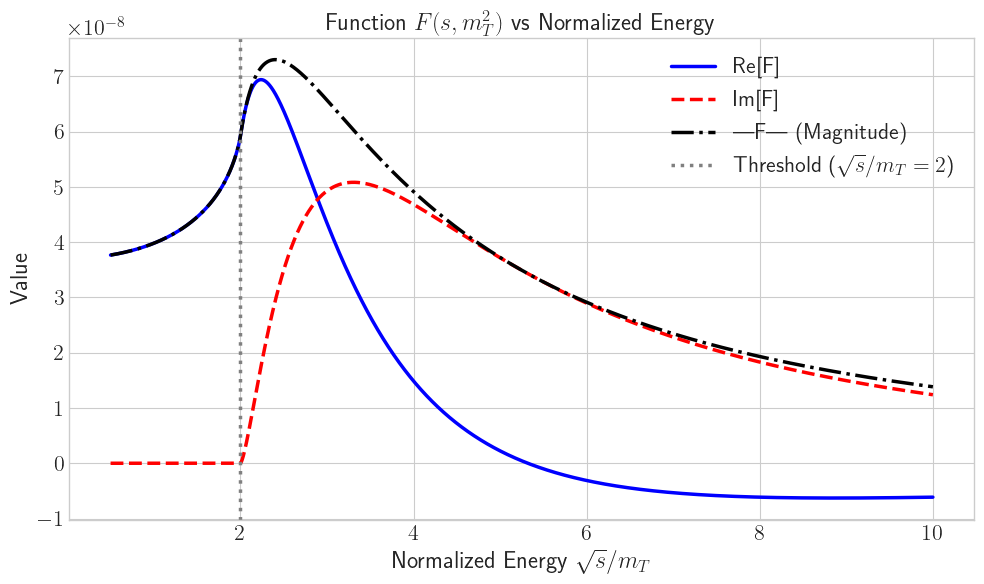

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2.5

# --- 2. PARAMETERS ---
mT = 1500.0           # Top mass in GeV
mT_squared = mT**2
threshold_norm = 2.0 # Threshold is always at 2*m / m = 2

# --- 3. FUNCTIONS (As defined) ---
def L(s, mT_squared):
    """Calculates the function L(s, m_T^2)."""
    s = np.array(s, dtype=complex)
    mT_squared = complex(mT_squared)
    
    sqrt_term = np.sqrt(s * (s - 4 * mT_squared))
    numerator = sqrt_term + 2 * mT_squared - s
    denominator = 2 * mT_squared
    
    return np.log(numerator / denominator)

def F(s, mT_squared):
    """Calculates the function F(s, m_T^2)."""
    s = np.array(s, dtype=complex)
    mT_squared = complex(mT_squared)
    
    L_val = L(s, mT_squared)
    
    term1 =  mT_squared * L_val**2
    term2 = np.sqrt(s * (s - 4 * mT_squared)) * L_val
    term3 = 3 * s
    
    return (1 / s**2) * (term1 + term2 + term3)

# --- 4. GENERATE DATA ---
# Generate range for sqrt(s) from 0.5*m to 5*m
# We define x first (normalized), then get s from it
x_axis = np.linspace(0.5, 10.0, 10000) 

# Convert back to physical units to calculate the function
sqrt_s = x_axis * mT
s_values = sqrt_s**2

# Add epsilon for numerical stability
s_values_complex = s_values + 1e-10j

# Calculate F
f_values = F(s_values_complex, mT_squared)

# --- 5. PLOTTING ---
fig, ax = plt.subplots()

# Plot using the NORMALIZED x_axis
ax.plot(x_axis, np.real(f_values), label='Re[F]', color='blue')
ax.plot(x_axis, np.imag(f_values), label='Im[F]', color='red', linestyle='--')
ax.plot(x_axis, np.abs(f_values), label='|F| (Magnitude)', color='black', linestyle='-.')

# --- 6. FORMATTING ---
# Vertical line at normalized threshold (x = 2)
ax.axvline(x=threshold_norm, color='gray', linestyle=':', label=r'Threshold ($\sqrt{s}/m_T = 2$)')

ax.set_title(r"Function $F(s, m_T^2)$ vs Normalized Energy")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_T$")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
fig_config = {'figsize': (16, 10), 'layout': 'constrained'}
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

# --- 2. PARAMETERS ---
mPsi = 1500.0        # Heavy Mass (GeV)
mT_approx = 0.0      # Limit mT -> 0
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

# A. Article F(s) RAW
def F_article_raw(s, m_sq):
    s = np.array(s, dtype=complex)
    m_sq = complex(m_sq)
    L_val, delta_val = get_kinematics(s, np.sqrt(m_sq))
    
    term1 = m_sq * L_val**2
    term2 = delta_val * L_val 
    term3 = 3 * s
    return (1 / s**2) * (term1 + term2 + term3)

# B. Your Coefficients RAW
def get_VLF_coefficients_raw(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L_val, delta_val = get_kinematics(s, mPsi)
    scale = 1.0 / (  s**2)
    
    # Group 1: Gamma Term
    bracket1 = (mPsi**2 + mT**2) * L_val**2 + L_val * delta_val + 3 * s
    c_gamma = scale  * bracket1 
    
    # Group 2: Sandwich
    bracket2 = s * (L_val**2 + 4) + 2 * L_val * delta_val
    c_sand = scale * -1 * bracket2 
    
    # Group 3: Vec Diag
    bracket3 = L_val * delta_val + 2 * s
    c_vec_d = scale * 2 * bracket3 
    
    # Group 4: Vec Mix
    bracket4 = mPsi**2 * L_val**2 + 2 * L_val * delta_val + 5 * s
    c_vec_m = scale * -2 * bracket4 
    
    return c_gamma, c_sand, c_vec_d, c_vec_m

# --- 4. DATA GENERATION ---
# Use high resolution to find the intersection point accurately
x_axis = np.linspace(0.5, 5.0, 2000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

f_art = F_article_raw(s_values, mPsi**2)
c1, c2, c3, c4 = get_VLF_coefficients_raw(s_values, mPsi, mT_approx)



# --- 5. FIND INTERSECTION (Re = Im) ---
# We look for the point where abs(Re - Im) is minimal
# Ignore x < 2.0 (below threshold Im is 0, so Re=Im is meaningless/trivial)
mask_above_threshold = x_axis > 2.01
diff = np.abs(np.real(c1_flipped[mask_above_threshold]) - np.imag(c1_flipped[mask_above_threshold]))
local_idx = np.argmin(diff)
# Map back to global index
global_idx = np.where(mask_above_threshold)[0][local_idx]
x_cross = x_axis[global_idx]
y_cross = np.real(c1_flipped[global_idx])

# --- 6. PLOTTING ---
fig, ax = plt.subplots(**fig_config)

plot_data = [
    (f_art, 'black', 'Article F(s)', 3.5),
    (c1_flipped, 'blue', 'Grp 1 (Flipped -)', 2),
    (c2, 'red', 'Grp 2 (Sandwich)', 1.5),
    (c3, 'green', 'Grp 3 (Vec Diag)', 1.5),
    (c4, 'orange', 'Grp 4 (Vec Mix)', 1.5)
]

for data, col, lbl, width in plot_data:
    ax.plot(x_axis, np.real(data), color=col, linestyle='-', linewidth=width, label=f'{lbl} - Re')
    ax.plot(x_axis, np.imag(data), color=col, linestyle='--', linewidth=width, label=f'{lbl} - Im')
    ax.plot(x_axis, np.abs(data), color=col, linestyle=':', linewidth=width+1, label=f'{lbl} - Abs')

# --- 7. FORMATTING ---
ax.set_title("Comparison with Intersection Point (Re = Im)")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Raw Value (SymLog Scale)")
ax.set_yscale('symlog', linthresh=1e-8)

# Threshold Line
ax.axvline(2.0, color='gray', linestyle='-', linewidth=1)
ax.text(0.41, 0.95, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

# INTERSECTION LINE
ax.axvline(x_cross, color='purple', linestyle='-.', linewidth=2)
# Text label for intersection (using relative y-coordinates to be safe)
ax.text(x_cross + 0.05, 0.5, f'Re = Im\n(x ≈ {x_cross:.2f})', 
        transform=ax.get_xaxis_transform(), color='purple', rotation=90, verticalalignment='center')

# Legend
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, title="Legend")

plt.show()

# --- 8. ANALYSIS ---
print(f"Intersection found at normalized energy x = {x_cross:.4f}")
print(f"At this point, Real part = {y_cross:.4e}")
print(f"This corresponds to a phase angle of 45 degrees (pi/4).")

NameError: name 'c1_flipped' is not defined

# Analysis of One-Loop EFT Coefficients

This notebook analyzes the coefficients of the one-loop effective field theory amplitude. Based on the calculation performed using FeynCalc, the total amplitude $\mathcal{M}^\mu$ is decomposed into a set of independent Lorentz structures.

The amplitude is parameterized as:
$$
\mathcal{M}^\mu = \sum_{i=1}^{5} C_i(s) \cdot \mathcal{O}_i^\mu
$$

where $C_i(s)$ are the scalar coefficients plotted below, and $\mathcal{O}_i^\mu$ are the associated tensor basis structures.

### 1. The Basis Definitions
We define the basis structures $\mathcal{O}_i^\mu$ to match the physical properties of the interaction:

* **Group 1 (The Form Factor):** The dominant contribution, matching the article's definition of $F(s)$.
    $$\mathcal{O}_1^\mu = -s \gamma^\mu$$

* **Group 2 (Mixed Vectors):** The symmetric combination of mixed momentum-spinor contractions.
    $$\mathcal{O}_2^\mu = \slashed{p}_1 p_2^\mu + \slashed{p}_2 p_1^\mu$$

* **Group 3 (Sandwich $2 \to 1$):** The spin-flip structure with the loop momentum flow $p_2 \to p_1$.
    $$\mathcal{O}_3^\mu = - \slashed{p}_2 \gamma^\mu \slashed{p}_1$$

* **Group 4 (Sandwich $1 \to 2$):** The spin-flip structure with the loop momentum flow $p_1 \to p_2$.
    $$\mathcal{O}_4^\mu = - \slashed{p}_1 \gamma^\mu \slashed{p}_2$$

* **Group 5 (Diagonal Vectors):** The symmetric combination where spinor and vector indices match.
    $$\mathcal{O}_5^\mu = - (\slashed{p}_1 p_1^\mu + \slashed{p}_2 p_2^\mu)$$

### 2. Analytical Structure of Coefficients
The scalar coefficients $C_i(s)$ are derived from the loop integrals expressed in terms of the functions $L(s, m^2)$ and $\Delta(s, m^2)$. The global prefactor is $\mathcal{N} = -\frac{1}{32\pi^4 s^2}$.

| Coefficient | Analytical Expression (Raw Output) | Physical Significance |
| :--- | :--- | :--- |
| **$C_1(s)$** | $-\mathcal{N} \left[ (m_{\Psi}^2 + m_T^2)L^2 + L\Delta + 3s \right]$ | **Form Factor:** Contains the threshold cusp and logarithms. Matches standard EFT results. |
| **$C_2(s)$** | $\mathcal{N} \left[ -2(m_{\Psi}^2 L^2 + 2L\Delta + 5s) \right]$ | **Vector Correction:** Subleading at low energy, grows with $\sqrt{s}$ in the amplitude. |
| **$C_3(s)$** | $-\mathcal{N} \left[ -(2L\Delta + s(L^2+4)) \right]$ | **Absorptive Sandwich:** Contributes to the imaginary part above threshold. |
| **$C_4(s)$** | $-\mathcal{N} \left[ 2(L\Delta + 2s) \right]$ | **Symmetric Sandwich:** Identical scalar structure to the diagonal vectors ($C_5$). |
| **$C_5(s)$** | $-\mathcal{N} \left[ 2(L\Delta + 2s) \right]$ | **Diagonal Vector:** Numerically identical to $C_4$ due to loop symmetry. |

### 3. Kinematic Functions
The coefficients depend on the standard scalar one-loop integral functions:
$$
\Delta(s, m^2) = \sqrt{s(s - 4m^2)}
$$
$$
L(s, m^2) = \log\left( \frac{2m^2 - s + \Delta}{2m^2} \right)
$$

### One-Loop Amplitude Decomposition

The one-loop effective amplitude $\mathcal{M}^\mu$ is decomposed into a basis of five independent Lorentz structures:

$$
\mathcal{M}^\mu = \frac{1}{32\pi^4 s^2} \sum_{i=1}^{5} C_i(s) \cdot \mathcal{O}_i^\mu
$$

#### 1. Kinematic Functions
The coefficients depend on the standard one-loop scalar functions $L(s, m_\Psi^2)$ and $\Delta(s, m_\Psi^2)$:

$$
\Delta(s, m_\Psi^2) = \sqrt{s(s - 4m_\Psi^2)}
$$

$$
L(s, m_\Psi^2) = \log\left( \frac{2m_\Psi^2 - s + \Delta}{2m_\Psi^2} \right)
$$

---

#### 2. Coefficients and Structures

**Group 1: The Form Factor**
This is the dominant term containing the threshold cusp.

$$
\mathcal{O}_1^\mu = s \gamma^\mu
$$
$$
C_1(s) = (m_\Psi^2 + m_T^2)L^2 + L\Delta + 3s
$$

**Group 2: Mixed Vector Correction**
Symmetric combination of mixed momentum-spinor contractions.

$$
\mathcal{O}_2^\mu = \slashed{p}_1 p_2^\mu + \slashed{p}_2 p_1^\mu
$$
$$
C_2(s) = -2 \left( m_\Psi^2 L^2 + 2L\Delta + 5s \right)
$$

**Group 3: Absorptive Sandwich ($2 \to 1$)**
Spin-flip contribution with loop momentum flow $p_2 \to p_1$.

$$
\mathcal{O}_3^\mu = \slashed{p}_2 \gamma^\mu \slashed{p}_1
$$
$$
C_3(s) = -\left( 2L\Delta + s(L^2 + 4) \right)
$$

**Group 4: Symmetric Sandwich ($1 \to 2$)**
Spin-flip contribution with loop momentum flow $p_1 \to p_2$.

$$
\mathcal{O}_4^\mu = \slashed{p}_1 \gamma^\mu \slashed{p}_2
$$
$$
C_4(s) = 2(L\Delta + 2s)
$$

**Group 5: Diagonal Vector Correction**
Symmetric combination where spinor and vector indices match.

$$
\mathcal{O}_5^\mu = \slashed{p}_1 p_1^\mu + \slashed{p}_2 p_2^\mu
$$
$$
C_5(s) = 2(L\Delta + 2s)
$$

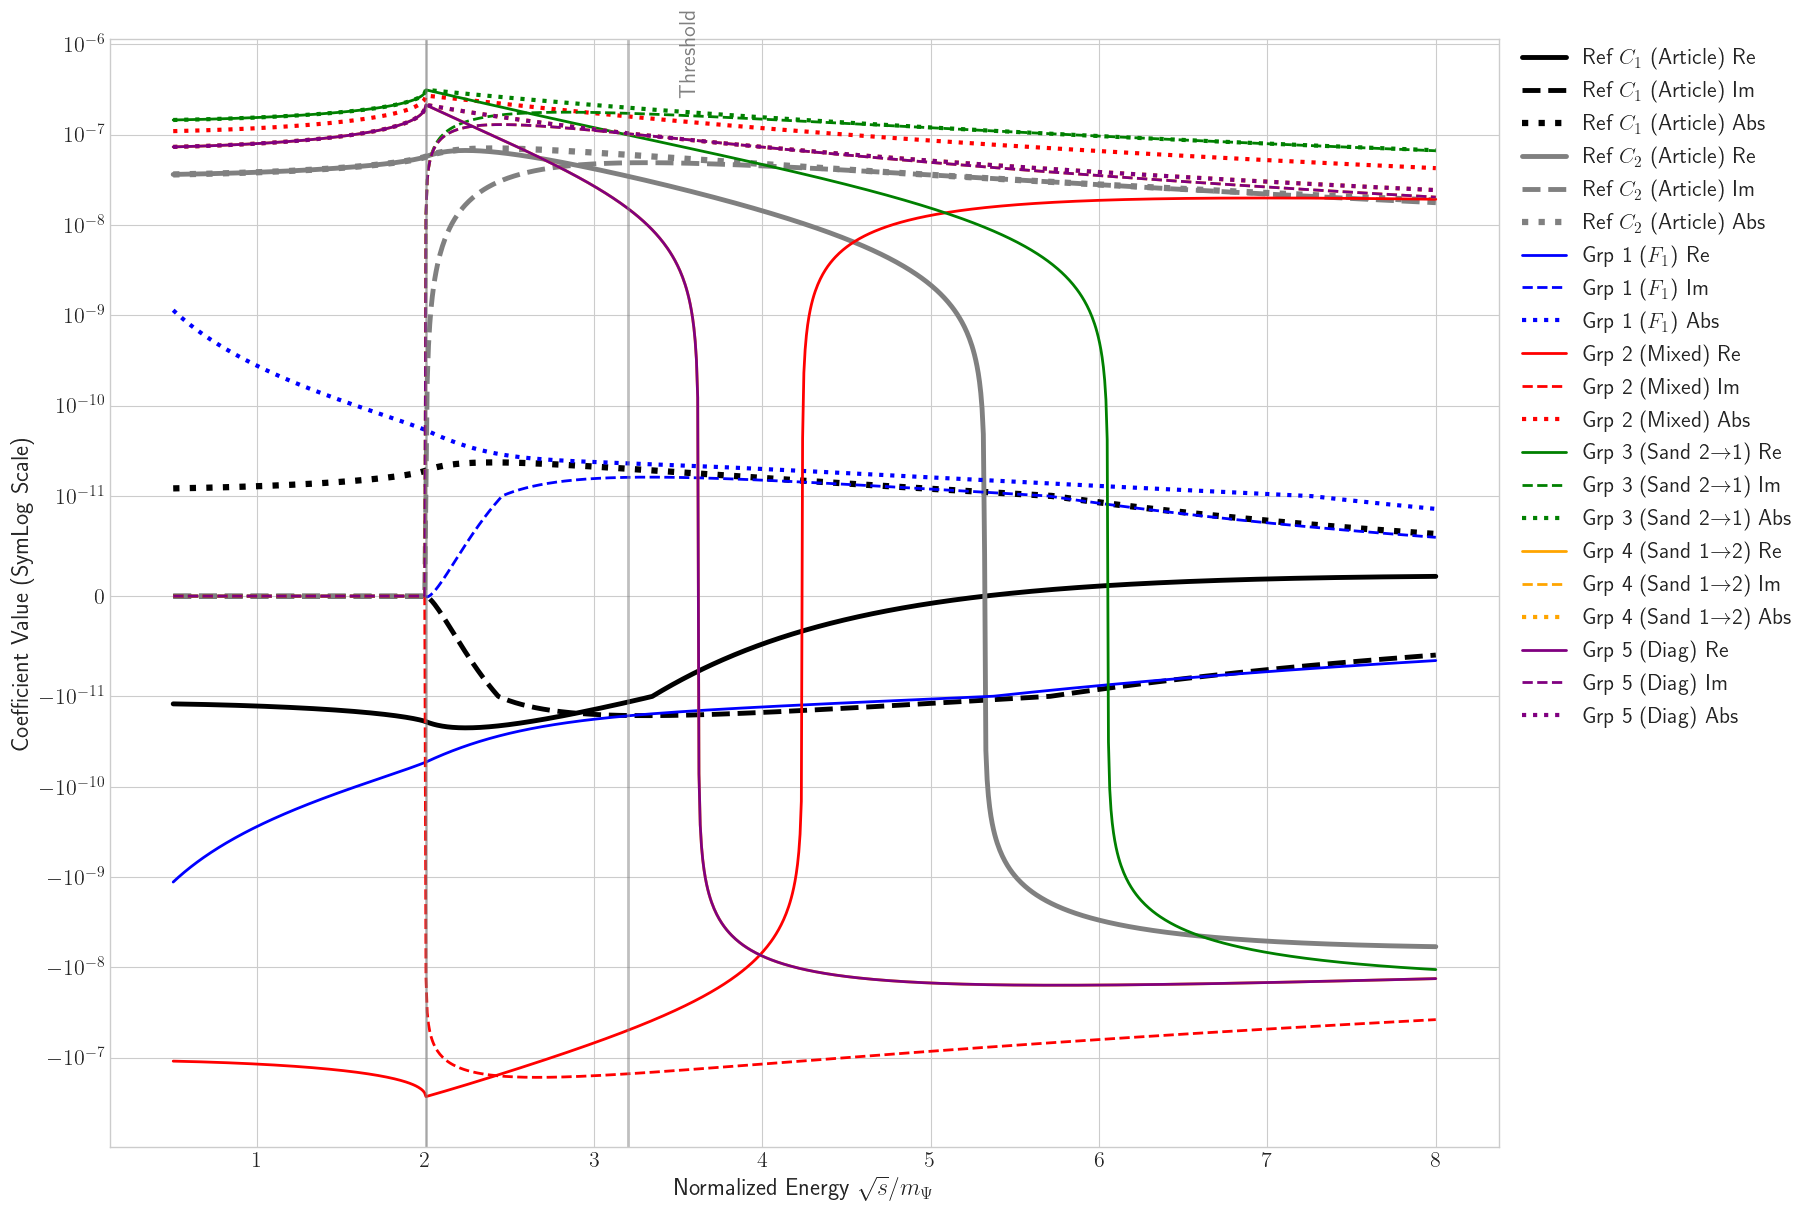

In [20]:

fig_config = {'figsize': (18, 12), 'layout': 'constrained'}
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 2

mPsi = 1500.0
mT_approx = 172.5
pi = np.pi

def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_basis_coefficients(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    scale = 1.0 / (32.0 * pi**4 * s**2)
    
    raw_B1 = (mPsi**2 + mT**2) * L**2 + L * delta +  s
    raw_B2 = -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s)
    raw_B3 = -(2 * L * delta + s * (L**2 + 4))
    raw_B4 = 2 * (L * delta + 2 * s)
    raw_B5 = 2 * (L * delta + 2 * s) 

    c1 = scale * raw_B1
    c2 = scale * raw_B2
    c3 = scale * raw_B3
    c4 = scale * raw_B4
    c5 = scale * raw_B5
    
    return c1, c2, c3, c4, c5

def get_article_coefficients(s, mPsi):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    scalar_part = (1.0 / (32.0 * pi**4 * s**2)) * (mPsi**2 * L**2 + L * delta + 3 * s)
    
    c1_art = -scalar_part
    c2_art = 2.0 * scalar_part
    
    return c1_art, c2_art

x_axis = np.linspace(0.5, 8.0, 1000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

c1, c2, c3, c4, c5 = get_basis_coefficients(s_values, mPsi, mT_approx)
c1_art, c2_art = get_article_coefficients(s_values, mPsi)

fig, ax = plt.subplots(**fig_config)

m_scale = mPsi

lines_to_plot = [
    (c1_art, 'black', r'Ref $C_1$ (Article)', 1.5),
    (c2_art * m_scale, 'gray', r'Ref $C_2$ (Article)', 1.5),
    (c1, 'blue', r'Grp 1 ($F_1$)', 0),
    (c2 * m_scale, 'red', r'Grp 2 (Mixed)', 0),
    (c3 * m_scale, 'green', r'Grp 3 (Sand 2$\to$1)', 0),
    (c4 * m_scale, 'orange', r'Grp 4 (Sand 1$\to$2)', 0),
    (c5 * m_scale, 'purple', r'Grp 5 (Diag)', 0)
]

for data, col, lbl, w_off in lines_to_plot:
    base_lw = 2 + w_off
    ax.plot(x_axis, np.real(data), color=col, linestyle='-', linewidth=base_lw, label=f'{lbl} Re')
    ax.plot(x_axis, np.imag(data), color=col, linestyle='--', linewidth=base_lw, label=f'{lbl} Im')
    ax.plot(x_axis, np.abs(data), color=col, linestyle=':', linewidth=base_lw+1, label=f'{lbl} Abs')

ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Coefficient Value (SymLog Scale)")
ax.set_yscale('symlog', linthresh=1e-11)

ax.axvline(2.0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(3.2, color='gray', linestyle='-', alpha=0.5)
ax.text(0.41, 0.95, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, ncol=1)

plt.show()

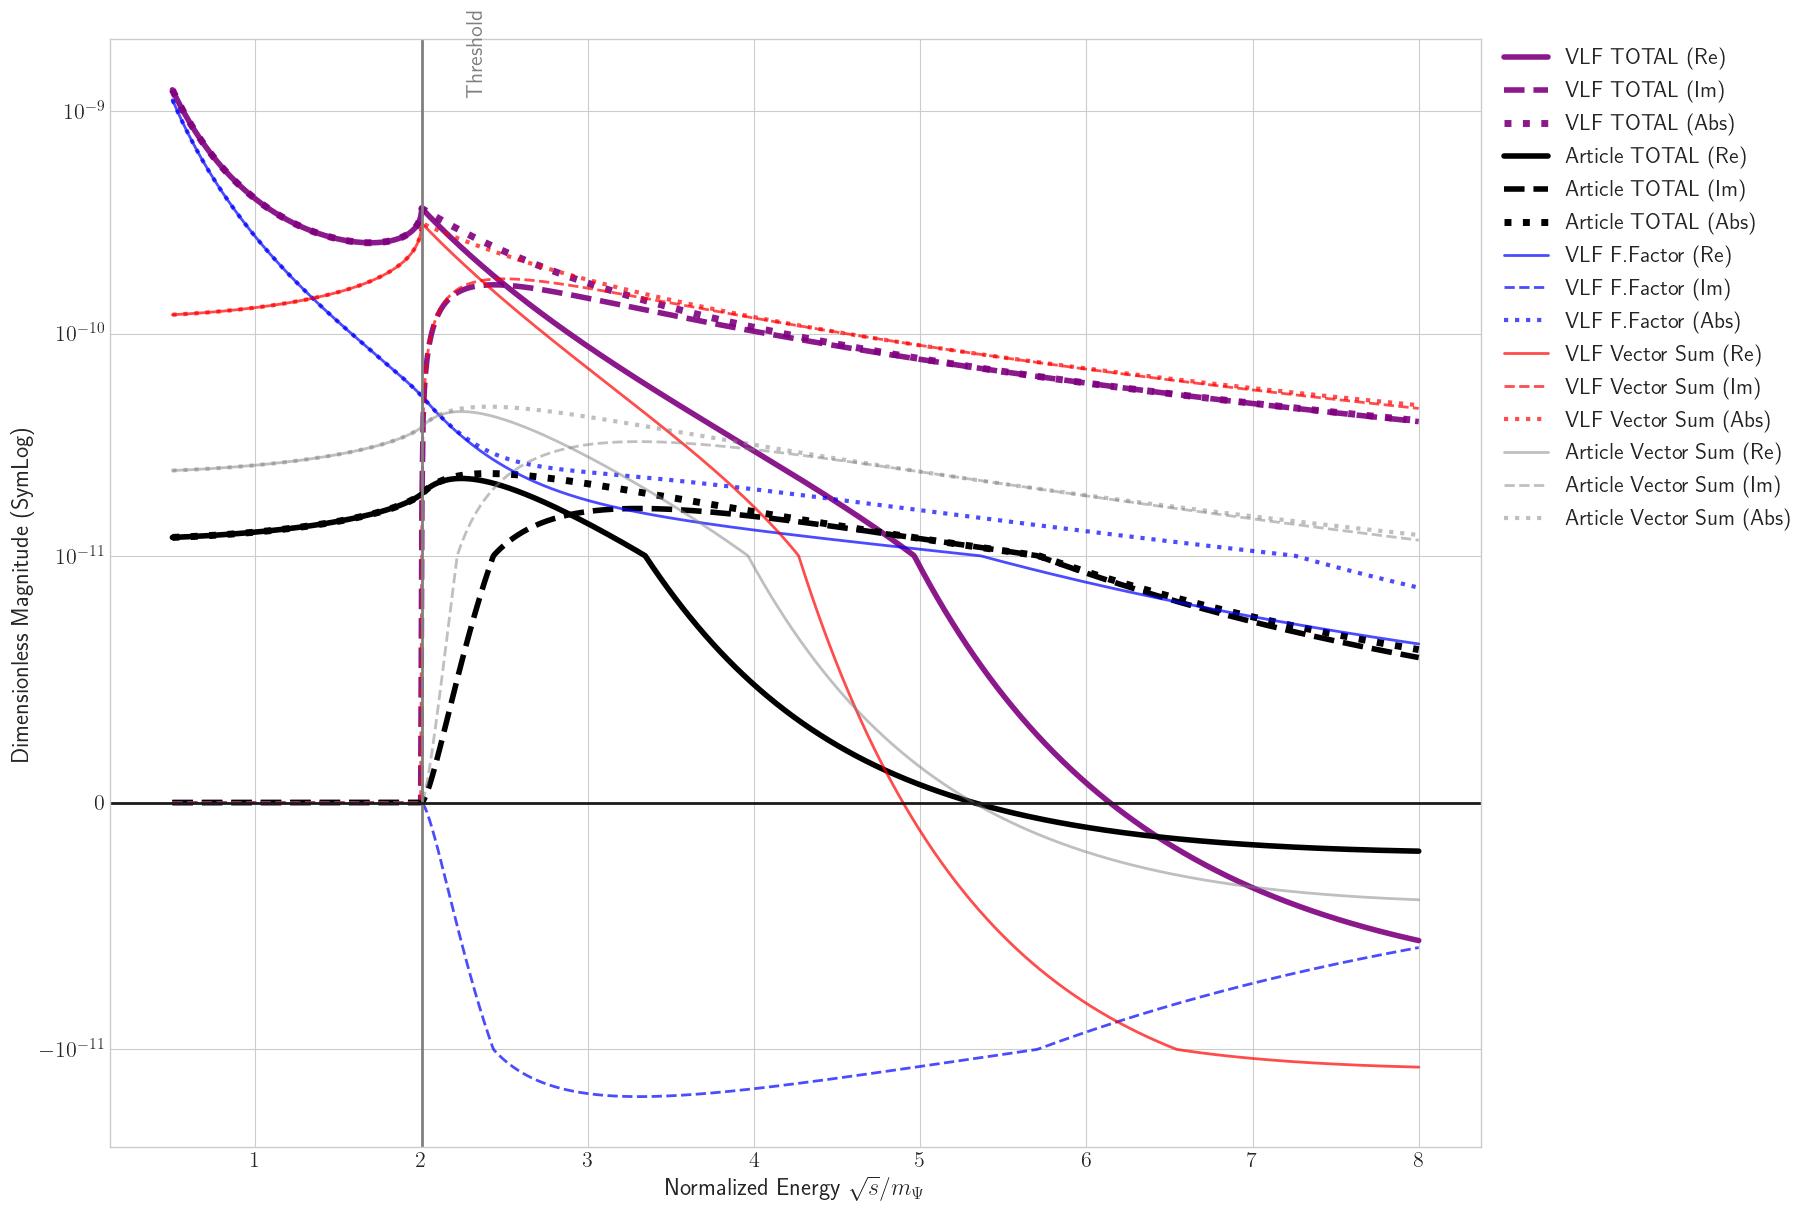

In [21]:

fig_config = {'figsize': (18, 12), 'layout': 'constrained'}
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 2

mPsi = 1500.0
mT_approx = 0
pi = np.pi

def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_full_analysis(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    scale = 1.0 / (32.0 * pi**4 * s**2)
    
    raw_B1 = ((mPsi**2 + mT**2) * L**2 + L * delta +  s)
    raw_B2 = -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s)
    raw_B3 = -(2 * L * delta + s * (L**2 + 4))
    raw_B4 = 2 * (L * delta + 2 * s)
    raw_B5 = 2 * (L * delta + 2 * s) 

    VLF_c1 = -scale * raw_B1
    
    VLF_vec_sum_raw = scale * (raw_B2 + raw_B3 + raw_B4 + raw_B5)
    VLF_vec_component = VLF_vec_sum_raw 
    
    VLF_total = (VLF_c1 + VLF_vec_component)
    
    scalar_part = scale * (mPsi**2 * L**2 + L * delta + 3 * s)
    
    art_c1 = -scalar_part 
    
    art_vec_component = (2.0 * scalar_part) 
    
    art_total = art_c1 + art_vec_component
    
    return (VLF_c1, VLF_vec_component, VLF_total), (art_c1, art_vec_component, art_total)

x_axis = np.linspace(0.5, 8.0, 1000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

(u_c1, u_vec, u_tot), (a_c1, a_vec, a_tot) = get_full_analysis(s_values, mPsi, mT_approx)

fig, ax = plt.subplots(**fig_config)

def plot_set(ax, x, data, color, label_base, alpha=1.0, lw_adj=0):
    ax.plot(x, np.real(data), color=color, linestyle='-', linewidth=2+lw_adj, alpha=alpha, label=f'{label_base} (Re)')
    ax.plot(x, np.imag(data), color=color, linestyle='--', linewidth=2+lw_adj, alpha=alpha, label=f'{label_base} (Im)')
    ax.plot(x, np.abs(data), color=color, linestyle=':', linewidth=3+lw_adj, alpha=alpha, label=f'{label_base} (Abs)')

plot_set(ax, x_axis, u_tot, 'purple', 'VLF TOTAL', alpha=0.9, lw_adj=2)
plot_set(ax, x_axis, a_tot, 'black', 'Article TOTAL', alpha=1, lw_adj=2)

plot_set(ax, x_axis, u_c1, 'blue', 'VLF F.Factor', alpha=0.7)

plot_set(ax, x_axis, u_vec, 'red', 'VLF Vector Sum', alpha=0.7)
plot_set(ax, x_axis, a_vec, 'gray', 'Article Vector Sum', alpha=0.5)


ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Dimensionless Magnitude (SymLog)")
ax.set_yscale('symlog', linthresh=1e-11)

ax.axvline(2.0, color='gray', linestyle='-')
ax.axhline(0.0, color='k', linestyle='-')
ax.text(0.26, 0.95, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, ncol=1)

plt.show()

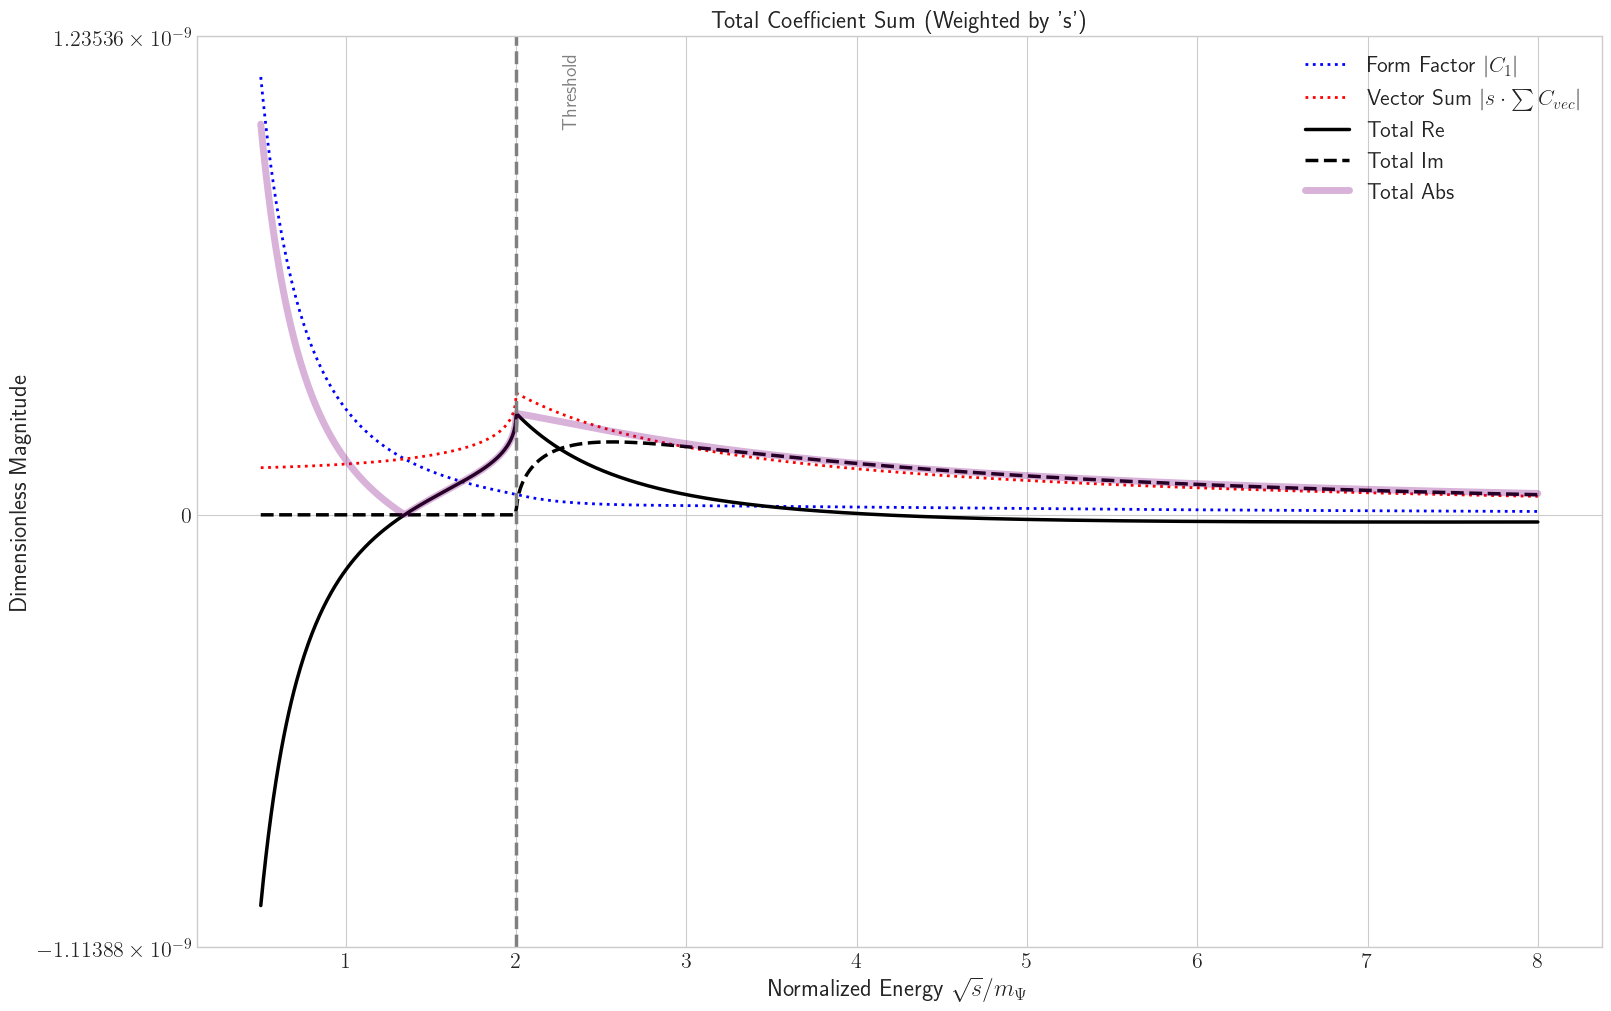

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
fig_config = {'figsize': (16, 10), 'layout': 'constrained'}
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2.5

# --- 2. PARAMETERS ---
mPsi = 1500.0        # Heavy Mass (GeV)
mT_approx = 0.0      # Limit mT -> 0
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_basis_coefficients(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L, delta = get_kinematics(s, mPsi)
    
    # Scale (Dimension -4)
    scale = 1.0 / (32.0 * pi**4 * s**2)
    
    # Raw Brackets (Dimension 2)
    raw_B1 = (mPsi**2 + mT**2) * L**2 + L * delta +  s
    raw_B2 = -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s)
    raw_B3 = -(2 * L * delta + s * (L**2 + 4))
    raw_B4 = 2 * (L * delta + 2 * s)
    raw_B5 = 2 * (L * delta + 2 * s)

    # Coefficients
    # C1 is Dimensionless
    c1 = scale  * raw_B1
    # C2-C5 are Dimension -2
    c2 = scale * raw_B2
    c3 = scale * raw_B3
    c4 = scale * raw_B4
    c5 = scale * raw_B5
    
    return c1, c2, c3, c4, c5

# --- 4. DATA GENERATION ---
x_axis = np.linspace(0.5, 8.0, 1000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

c1, c2, c3, c4, c5 = get_basis_coefficients(s_values, mPsi, mT_approx)

# --- 5. SUMMATION ---
# Weight vector coefficients by 's' to make them dimensionless
c_vector_sum = (c2 + c3 + c4 + c5) 
c_total = c1 + c_vector_sum

# --- 6. PLOTTING ---
fig, ax = plt.subplots(**fig_config)

# Plot Components
ax.plot(x_axis, np.abs(c1), color='blue', linestyle=':', linewidth=2, label=r'Form Factor $|C_1|$')
ax.plot(x_axis, np.abs(c_vector_sum), color='red', linestyle=':', linewidth=2, label=r'Vector Sum $|s \cdot \sum C_{vec}|$')

# Plot Total
ax.plot(x_axis, np.real(c_total), color='black', linestyle='-', label=r'Total Re')
ax.plot(x_axis, np.imag(c_total), color='black', linestyle='--', label=r'Total Im')
ax.plot(x_axis, np.abs(c_total), color='purple', linewidth=5, alpha=0.3, label=r'Total Abs')

# Format
ax.set_title("Total Coefficient Sum (Weighted by 's')")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Dimensionless Magnitude")
ax.set_yscale('symlog', linthresh=1e-5)

ax.axvline(2.0, color='gray', linestyle='--')
ax.text(0.26, 0.9, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

ax.legend(loc='upper right')

plt.show()

<Figure size 1200x800 with 0 Axes>

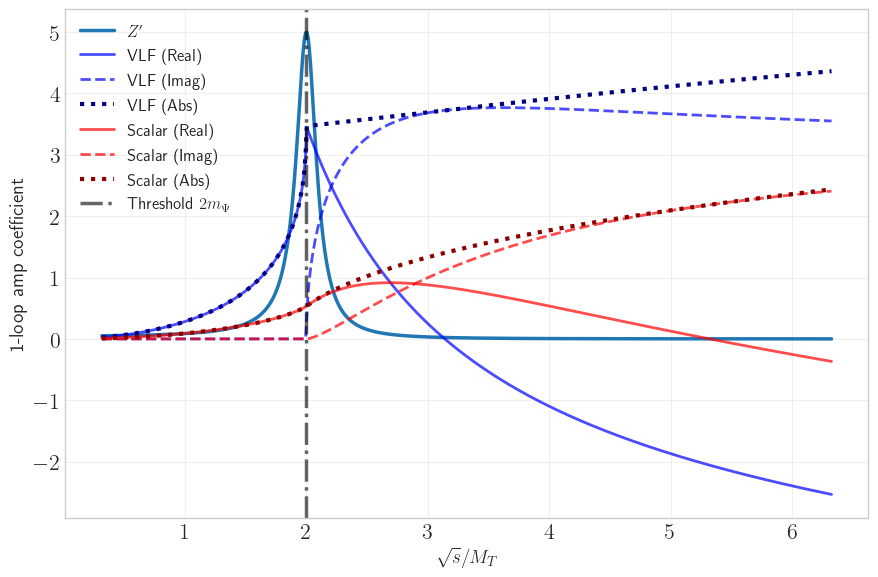

In [32]:

def breit_wigner(x, M_T, Gamma=20.0):
    """
    Calculates the relativistic Breit-Wigner shape.
    x     : sqrt(s_hat) / M_T
    M_T   : Reference mass (GeV)
    Gamma : Resonance width (GeV), fixed to 200 GeV
    """
    # Convert the dimensionless x back to s_hat (energy squared)
    s_hat = (x * M_T)**2
    
    # The resonance mass is exactly 2 * M_T
    M_res = 2.0 * M_T
    
    # Relativistic Breit-Wigner denominator: (s - M^2)^2 + (M * Gamma)^2
    denominator = (s_hat - M_res**2)**2 + (M_res * Gamma)**2
    
    return 1.0 / denominator

def get_kinematics(s, m):
    """
    Computes L(s, m) and Delta(s, m) based on the specific definitions:
    Delta = Sqrt[s * (s - 4*m^2)]
    L = Log[(Delta + 2*m^2 - s) / (2*m^2)]
    """
    # 1. Compute Delta (Sqrt[s(s - 4m^2)])
    # cmath.sqrt automatically handles the branch cut for s < 4m^2
    Delta = cmath.sqrt(s * (s - 4 * m**2))
    
    # 2. Compute L
    # Argument: (Delta + 2m^2 - s) / (2m^2)
    numerator = Delta + 2 * m**2 - s
    denominator = 2 * m**2
    
    # cmath.log automatically handles complex arguments (negative or complex numerator)
    L = cmath.log(numerator / denominator)
    
    return L, Delta

# Parameters
M_T = m = 1000.0  # Mass in GeV (or relevant unit)
# Define range of s (Center of Mass Energy squared)
# Extended range to 40*m^2 as requested in the snippet
s_values = np.linspace(0.1 * m**2, 40 * m**2, 1000)

# Initialize complex arrays
vlf_res = np.zeros_like(s_values, dtype=np.complex128)
scalar_res = np.zeros_like(s_values, dtype=np.complex128)

for i, s in enumerate(s_values):
    # Retrieve L and Delta using the correct definitions
    L, Delta = get_kinematics(s, m)
    
    # 1. VLF Contribution (Group 1 / Vector)
    # Formula: (s(s - m^2 L^2) + s L Delta) / s^2
    term1_vlf = s * (s - (m**2 * L**2))
    term2_vlf = s * L * Delta
    vlf_res[i] = (term1_vlf + term2_vlf) / s**2
    
    # 2. Scalar Contribution (Group 2 / Mixed)
    # Formula: (L(m^2 L + Delta) + 3s) / s
    term1_scalar = L * (m**2 * L + Delta)
    term2_scalar = 3 * s
    scalar_res[i] = (term1_scalar + term2_scalar) / s

# Plotting
x_axis = np.sqrt(s_values) / m 

plt.figure(figsize=(12, 8))
# Fixed Width
Gamma_fixed = 200.0 # GeV



plt.figure(figsize=(9, 6))


y_vals = breit_wigner(x_axis, MT, Gamma=Gamma_fixed)
    
# Normalize the peak to 1 for visual comparison of the shapes
y_normalized =5.0 *y_vals / np.max(y_vals)

label_str = r'$Z^\prime$'.format(M_T)
plt.plot(x_axis, y_normalized, color=color, linewidth=2.5, label=label_str)

# VLF Curves (Blue)
plt.plot(x_axis, vlf_res.real, label='VLF (Real)', color='blue', linestyle='-', linewidth=2, alpha=0.7)
plt.plot(x_axis, vlf_res.imag, label='VLF (Imag)', color='blue', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(x_axis, np.abs(vlf_res), label='VLF (Abs)', color='navy', linestyle=':', linewidth=3) # Made thick & distinct

# Scalar Curves (Red)
plt.plot(x_axis, scalar_res.real, label='Scalar (Real)', color='red', linestyle='-', linewidth=2, alpha=0.7)
plt.plot(x_axis, scalar_res.imag, label='Scalar (Imag)', color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(x_axis, np.abs(scalar_res), label='Scalar (Abs)', color='darkred', linestyle=':', linewidth=3) # Made thick & distinct

# Threshold Line at sqrt(s) = 2m
plt.axvline(2.0, color='black', linestyle='-.', alpha=0.6, label=r'Threshold $2m_\Psi$')

plt.xlabel(r'$\sqrt{s}/M_T$', fontsize=14)
plt.ylabel('1-loop amp coefficient', fontsize=14)

plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

#plt.savefig('FormFactor_comparison.png')

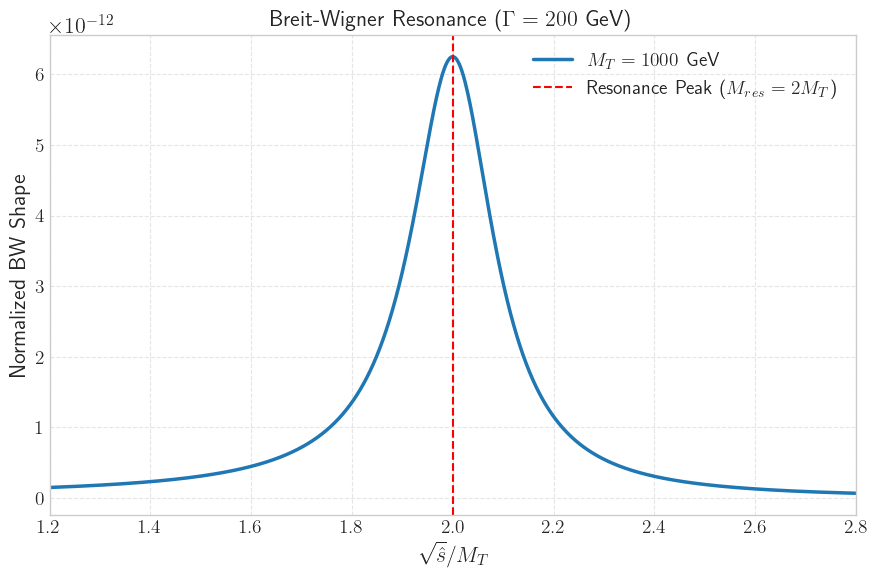

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def breit_wigner(x, M_T, Gamma=20.0):
    """
    Calculates the relativistic Breit-Wigner shape.
    x     : sqrt(s_hat) / M_T
    M_T   : Reference mass (GeV)
    Gamma : Resonance width (GeV), fixed to 200 GeV
    """
    # Convert the dimensionless x back to s_hat (energy squared)
    s_hat = (x * M_T)**2
    
    # The resonance mass is exactly 2 * M_T
    M_res = 2.0 * M_T
    
    # Relativistic Breit-Wigner denominator: (s - M^2)^2 + (M * Gamma)^2
    denominator = (s_hat - M_res**2)**2 + (M_res * Gamma)**2
    
    return 1.0 / denominator

# Define the x-axis range (sqrt(s)/M_T) around the peak at 2.0
x_vals = np.linspace(1.2, 2.8, 1000)

# Fixed Width
Gamma_fixed = 200.0 # GeV

# Plot for a few different M_T values to show how the 200 GeV width scales 
M_T_list = [1000.0] # GeV
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(9, 6))

for M_T, color in zip(M_T_list, colors):
    # Calculate the BW shape
    y_vals = breit_wigner(x_vals, M_T, Gamma=Gamma_fixed)
    
    # Normalize the peak to 1 for visual comparison of the shapes
    y_normalized = y_vals 
    
    label_str = r'$M_T = {:.0f}$ GeV'.format(M_T)
    plt.plot(x_vals, y_normalized, color=color, linewidth=2.5, label=label_str)

# Mark the peak explicitly
plt.axvline(x=2.0, color='red', linestyle='--', linewidth=1.5, 
            label=r'Resonance Peak ($M_{res} = 2M_T$)')

# Formatting the plot
plt.xlim(1.2, 2.8)
#plt.ylim(0, 1.05) # Linear scale is usually better to view the actual peak shape

plt.xlabel(r'$\sqrt{\hat{s}} / M_T$', fontsize=16)
plt.ylabel(r'Normalized BW Shape', fontsize=16)
plt.title(r'Breit-Wigner Resonance ($\Gamma = 200$ GeV)', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=14, loc='upper right', framealpha=0.9)

plt.tight_layout()
#plt.savefig('breit_wigner_peak.png', dpi=300)
plt.show()

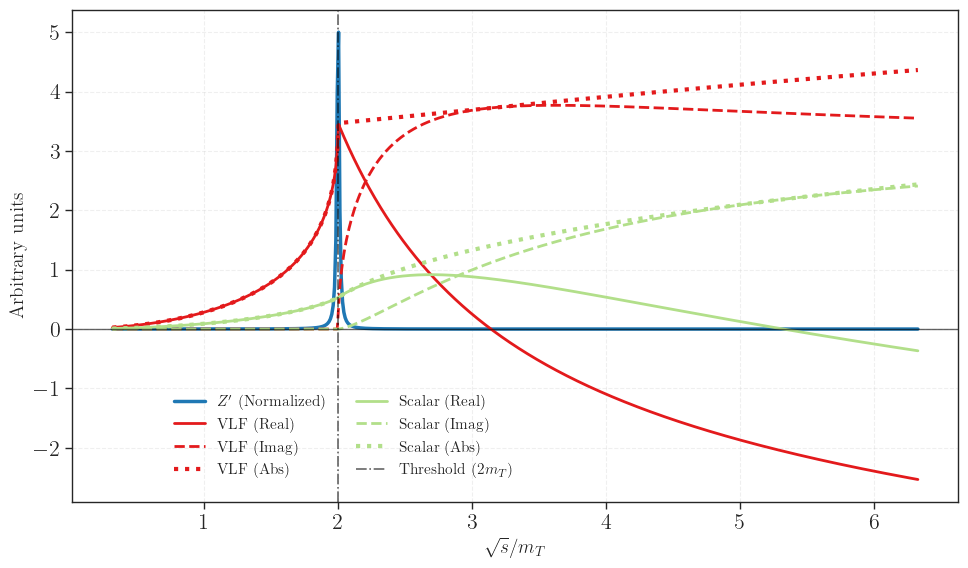

In [76]:

def breit_wigner(x, M_T, Gamma=20.0):
    """Calculates the relativistic Breit-Wigner shape."""
    s_hat = (x * M_T)**2
    M_res = 2.0 * M_T
    denominator = (s_hat - M_res**2)**2 + (M_res * Gamma)**2
    return 1.0 / denominator

# --- Parameters ---
M_T = m = 1000.0  
s_values = np.linspace(0.1 * m**2, 40 * m**2, 1000)
x_axis = np.sqrt(s_values) / m 

# --- Vectorized Complex Kinematics ---
# np.lib.scimath automatically handles complex roots when s < 4m^2
Delta = np.lib.scimath.sqrt(s_values * (s_values - 4 * m**2))
numerator = Delta + 2 * m**2 - s_values
L = np.lib.scimath.log(numerator / (2 * m**2))

# 1. VLF Contribution 
term1_vlf = s_values * (s_values - (m**2 * L**2))
term2_vlf = s_values * L * Delta
vlf_res = (term1_vlf + term2_vlf) / s_values**2

# 2. Scalar Contribution 
term1_scalar = L * (m**2 * L + Delta)
term2_scalar = 3 * s_values
scalar_res = (term1_scalar + term2_scalar) / s_values

# --- Visualization ---
plt.figure(figsize=(10, 6))

# Z' Resonance (Normalized)
Gamma_fixed = 20.0
y_vals = breit_wigner(x_axis, M_T, Gamma=Gamma_fixed)
y_normalized = 5.0 * y_vals / np.max(y_vals)
plt.plot(x_axis, y_normalized, color=colors[1], linewidth=2.5, label=r'$Z^\prime$ (Normalized)')

# VLF Curves 
plt.plot(x_axis, vlf_res.real, label='VLF (Real)', color=colors[5], linestyle='-', linewidth=2)
plt.plot(x_axis, vlf_res.imag, label='VLF (Imag)', color=colors[5], linestyle='--', linewidth=2)
plt.plot(x_axis, np.abs(vlf_res), label='VLF (Abs)', color=colors[5], linestyle=':', linewidth=3, alpha=1)

# Scalar Curves 
plt.plot(x_axis, scalar_res.real, label='Scalar (Real)', color=colors[2], linestyle='-', linewidth=2)
plt.plot(x_axis, scalar_res.imag, label='Scalar (Imag)', color=colors[2], linestyle='--', linewidth=2)
plt.plot(x_axis, np.abs(scalar_res), label='Scalar (Abs)', color=colors[2], linestyle=':', linewidth=3, alpha=1)

# Formatting
plt.axvline(2.0, color='black', linestyle='-.', alpha=0.6, label=r'Threshold ($2m_T$)')
plt.axhline(0.0, color='black', linewidth=1, alpha=0.6) # Zero baseline

plt.xlabel(r'$\sqrt{s}/m_T$', fontsize=14)
plt.ylabel('Arbitrary units', fontsize=14)


plt.legend(fontsize=11, loc='lower left', bbox_to_anchor=(0.1, 0.02), framealpha=1, ncol=2)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig('FormFactor_comparison.png', dpi=300)
plt.show()

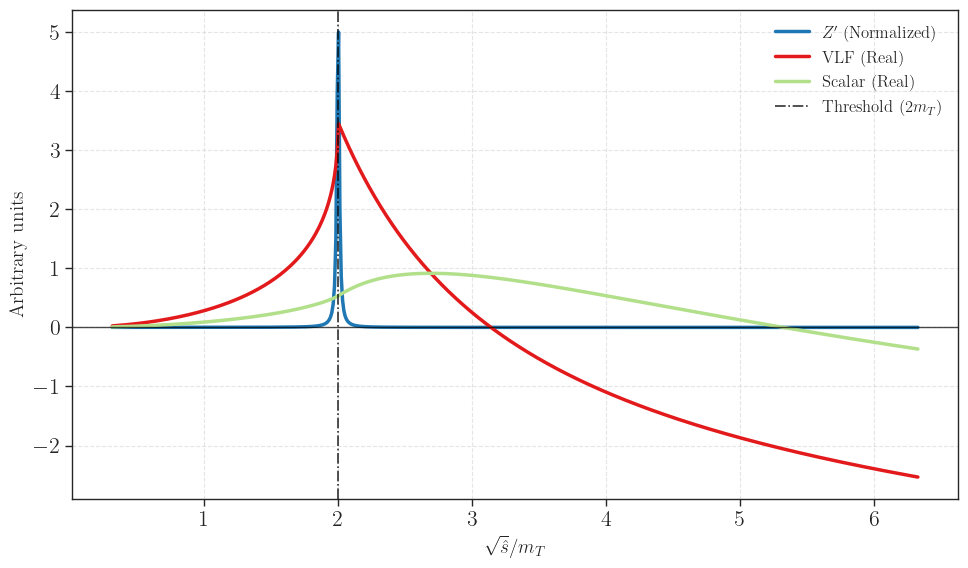

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def breit_wigner(x, M_T, Gamma=200.0):
    """Calculates the relativistic Breit-Wigner shape."""
    s_hat = (x * M_T)**2
    M_res = 2.0 * M_T
    denominator = (s_hat - M_res**2)**2 + (M_res * Gamma)**2
    return 1.0 / denominator

# --- Parameters ---
M_T = m = 1000.0  
s_values = np.linspace(0.1 * m**2, 40 * m**2, 1000)
x_axis = np.sqrt(s_values) / m 

# --- Vectorized Complex Kinematics ---
Delta = np.lib.scimath.sqrt(s_values * (s_values - 4 * m**2))
numerator = Delta + 2 * m**2 - s_values
L = np.lib.scimath.log(numerator / (2 * m**2))

# 1. VLF Contribution 
term1_vlf = s_values * (s_values - (m**2 * L**2))
term2_vlf = s_values * L * Delta
vlf_res = (term1_vlf + term2_vlf) / s_values**2

# 2. Scalar Contribution 
term1_scalar = L * (m**2 * L + Delta)
term2_scalar = 3 * s_values
scalar_res = (term1_scalar + term2_scalar) / s_values

# --- Visualization ---
plt.figure(figsize=(10, 6))

# Z' Resonance (Normalized back to the shared axis)
y_vals = breit_wigner(x_axis, M_T, Gamma=20.0)
y_normalized = 5.0 * y_vals / np.max(y_vals)
plt.plot(x_axis, y_normalized, color=colors[1], linewidth=2.5, alpha=1, label=r'$Z^\prime$ (Normalized)')

# VLF and Scalar Curves (Real Only)
plt.plot(x_axis, vlf_res.real, label='VLF (Real)', color=colors[5], linestyle='-', linewidth=2.5)
plt.plot(x_axis, scalar_res.real, label='Scalar (Real)', color=colors[2], linestyle='-', linewidth=2.5)

# Formatting
plt.axvline(2.0, color='black', linestyle='-.', alpha=0.8, label=r'Threshold ($2m_T$)')
plt.axhline(0.0, color='black', linewidth=1, alpha=0.7) # Zero baseline

plt.xlabel(r'$\sqrt{\hat{s}}/m_T$', fontsize=14)
plt.ylabel('Arbitrary units', fontsize=14)
plt.grid(True, alpha=0.5, linestyle='--')

plt.legend(fontsize=12, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('Form_Factor_real.png')

plt.show()